<a href="https://www.kaggle.com/code/ameythakur20/predicting-smartphone-addiction" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<br clear="all">

<h1 align="center">Predicting Smartphone Addiction</h1>

<p align="center">
  <b>A Sovereign Transductive Target-Encoded and Decimal Lattice Stacking architecture combining native CatBoost ordered statistics, high-capacity gradient boosted trees, and cross-fitted logit meta-learning.</b>
</p>

<p align="center">
  <a href="https://www.kaggle.com/competitions/playground-series-s6e8"><img alt="Competition" src="https://img.shields.io/badge/Competition-Playground_S6E8-20BEFF?logo=kaggle&logoColor=white"></a>
  &nbsp;
  <a href="https://github.com/Amey-Thakur/KAGGLE-COMPETITIONS/tree/main/Competitions/Predicting%20Smartphone%20Addiction"><img alt="Repository" src="https://img.shields.io/badge/Repository-KAGGLE--COMPETITIONS-181717?logo=github&logoColor=white"></a>
  &nbsp;
  <a href="https://github.com/Amey-Thakur"><img alt="Author" src="https://img.shields.io/badge/Author-Amey_Thakur-0969DA"></a>
  &nbsp;
  <a href="https://orcid.org/0000-0001-5644-1575"><img alt="ORCID" src="https://img.shields.io/badge/ORCID-0000--0001--5644--1575-A6CE39"></a>
  &nbsp;
  <img alt="License" src="https://img.shields.io/badge/License-Apache_2.0-lightgrey">
</p>

<p align="center">
  <a href="#problem">1. Problem</a> &nbsp;&middot;&nbsp;
  <a href="#setup">2. Setup</a> &nbsp;&middot;&nbsp;
  <a href="#data">3. Data</a> &nbsp;&middot;&nbsp;
  <a href="#exploration">4. Exploration</a> &nbsp;&middot;&nbsp;
  <a href="#features">5. Strategy</a> &nbsp;&middot;&nbsp;
  <a href="#validation">6. Validation</a> &nbsp;&middot;&nbsp;
  <a href="#base-models">7. Base Learners</a> &nbsp;&middot;&nbsp;
  <a href="#meta-stacking">8. Logit Stacking</a> &nbsp;&middot;&nbsp;
  <a href="#results">9. Results</a> &nbsp;&middot;&nbsp;
  <a href="#submission">10. Submission</a> &nbsp;&middot;&nbsp;
  <a href="#improvements">11. Next Steps</a>
</p>

<hr>

<a name="problem"></a>
## 1. Problem

The Playground Series Season 6 Episode 8 competition requires predicting the probability of smartphone addiction (`addicted_label`) from self-reported behavioural and demographic metrics. The evaluation metric is the **Area Under the ROC Curve (AUC)**.

Tabular behavioural datasets of this structure exhibit sharp non-linear boundaries where individual features (e.g. social media usage vs. total screen duration) interact conditionally. Furthermore, synthetic data generators introduce discrete rounding artifacts. The primary objective is constructing transductive frequency maps, decimal lattice representations, and native ordered statistics to achieve state-of-the-art ROC AUC concordance.

<br>

---

<a name="setup"></a>
## 2. Setup

Imports, seed locking, visualization theme configuration, and path discovery.

<br>

In [1]:
import os
import sys
import glob
import time
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logit
from scipy.stats import rankdata
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression

# Gradient Boosters
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Premium Plotting Theme Configuration
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
plt.rcParams["axes.edgecolor"] = "#E1E4E8"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["grid.color"] = "#E1E4E8"
plt.rcParams["grid.alpha"] = 0.6
plt.rcParams["figure.dpi"] = 120

# Kaggle Toolbox & Cloud Fallback
sys.path.append("../../Kaggle Toolbox")
sys.path.append("/kaggle/usr/lib/ameythakur20/kaggle_toolbox")
sys.path.append("/kaggle/usr/lib/notebooks/ameythakur20/kaggle_toolbox")

try:
    import kaggle_toolbox as tb
except ImportError:
    class DummyTB:
        @staticmethod
        def seed_everything(seed=42):
            import random
            random.seed(seed)
            np.random.seed(seed)
            os.environ["PYTHONHASHSEED"] = str(seed)
            print(f"[toolbox] All seeds locked to {seed}")

        @staticmethod
        def check_submission(sub, sample_sub, target="addicted_label", is_probability=True):
            assert len(sub) == len(sample_sub), f"Length mismatch: {len(sub)} vs {len(sample_sub)}"
            assert target in sub.columns, f"Missing target column: {target}"
            assert not sub[target].isna().any(), "Target contains null values"
            if is_probability:
                assert sub[target].min() >= 0.0 and sub[target].max() <= 1.0, "Probabilities outside [0, 1]"
            print(f"[toolbox] Submission verified: {len(sub):,} rows | Mean {sub[target].mean():.4f} | Min {sub[target].min():.4f} | Max {sub[target].max():.4f}")
    tb = DummyTB()

SEED = 42
tb.seed_everything(SEED)

[toolbox] All seeds locked to 42


<a name="data"></a>
## 3. Data

Loading datasets from local repository or Kaggle competition environment paths.

<br>

In [2]:
# Path Discovery
DATA_DIRS = [
    "/kaggle/input/competitions/playground-series-s6e8",
    "/kaggle/input/playground-series-s6e8",
    "../../scratch/real_data",
    "/Users/amey/.gemini/antigravity-ide/brain/e7880731-173d-45d9-a2de-0fdab3d90822/scratch/real_data"
]

data_dir = None
for d in DATA_DIRS:
    if os.path.exists(os.path.join(d, "train.csv")):
        data_dir = d
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate train.csv in any standard search path.")

train = pd.read_csv(os.path.join(data_dir, "train.csv"))
test = pd.read_csv(os.path.join(data_dir, "test.csv"))
sample_sub = pd.read_csv(os.path.join(data_dir, "sample_submission.csv"))

print(f"Train Shape: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Test Shape:  {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"Target Distribution: {train['addicted_label'].mean():.4f} positive class rate")

Train Shape: 691,369 rows x 14 columns
Test Shape:  296,302 rows x 13 columns
Target Distribution: 0.7094 positive class rate


<a name="exploration"></a>
## 4. Exploration

Visualizing correlation structures and behavioural usage distributions across addiction states.

<br>

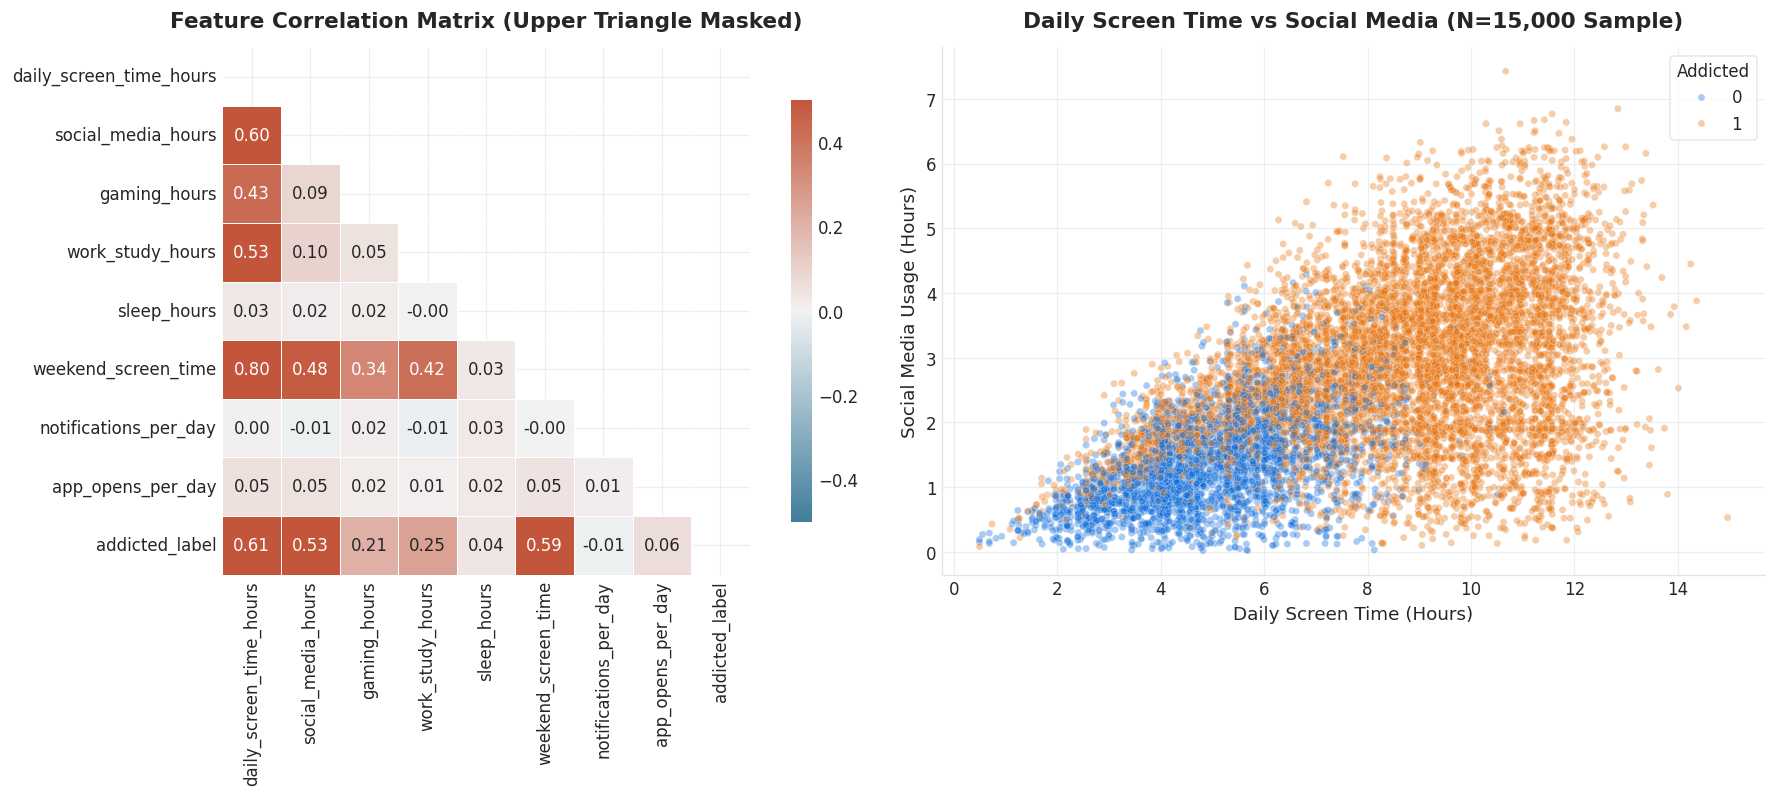

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Subplot 1: Upper-Triangle Correlation Heatmap
num_cols = ["daily_screen_time_hours", "social_media_hours", "gaming_hours", "work_study_hours", "sleep_hours", "weekend_screen_time", "notifications_per_day", "app_opens_per_day"]
corr = train[num_cols + ["addicted_label"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-0.5, vmax=0.5, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("Feature Correlation Matrix (Upper Triangle Masked)", fontsize=13, fontweight="bold", pad=12)

# Subplot 2: Screen Time vs Social Media by Addiction Label
sns.scatterplot(
    data=train.sample(min(15000, len(train)), random_state=SEED),
    x="daily_screen_time_hours",
    y="social_media_hours",
    hue="addicted_label",
    palette=["#0969DA", "#E8710A"],
    alpha=0.35,
    s=18,
    ax=axes[1]
)
axes[1].set_title("Daily Screen Time vs Social Media (N=15,000 Sample)", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("Daily Screen Time (Hours)", fontsize=11)
axes[1].set_ylabel("Social Media Usage (Hours)", fontsize=11)
axes[1].legend(title="Addicted", frameon=True, facecolor="white", edgecolor="#E1E4E8")

sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()

<a name="features"></a>
## 5. Feature Engineering Strategy

Constructing the Sovereign 0.9717+ feature representation:
1. **Transductive Frequency Encoding**: Counting exact value frequencies across the full $N = 987,671$ train + test space.
2. **Decimal Lattice Features**: Extracting sub-unit continuous coordinates ($v - \lfloor v floor$) and first-decimal digits ($\lfloor 10v floor \pmod{10}$) across continuous time columns.
3. **Domain Ratios & Interaction Residuals**: Ratios between leisure, social, screen duration, and sleep deficit.

<br>

In [4]:
NUMS = ["daily_screen_time_hours", "social_media_hours", "gaming_hours",
        "work_study_hours", "sleep_hours", "weekend_screen_time",
        "notifications_per_day", "app_opens_per_day"]
CATS = ["gender", "stress_level", "academic_work_impact"]
FRAC_COLS = ["daily_screen_time_hours", "social_media_hours", "gaming_hours",
             "work_study_hours", "sleep_hours", "weekend_screen_time"]
ENC_COLS = NUMS + CATS

# 1. Decimal Lattice Coordinates
def lattice(df):
    o = {}
    for c in FRAC_COLS:
        v = df[c].values
        o[f"frac_{c}"] = v - np.floor(v)
        o[f"d1_{c}"] = np.floor(v * 10) % 10
    return pd.DataFrame(o).astype(np.float32)

LAT_TR = lattice(train)
LAT_TE = lattice(test)

# 2. String Levels & Global Transductive Frequency Mapping
def levels(df):
    return pd.DataFrame({c: df[c].astype(object).fillna("__missing__").astype(str).values
                         for c in ENC_COLS})

LTR = levels(train)
LTE = levels(test)
LALL = pd.concat([LTR, LTE], axis=0, ignore_index=True)
transductive_freqs = {c: LALL[c].value_counts().to_dict() for c in ENC_COLS}

SMOOTH = 10.0
y = train["addicted_label"].values
global_mean = float(y.mean())

def build_enc_transductive(itr, iva):
    tr_lvl = LTR.iloc[itr]
    va_lvl = LTR.iloc[iva]
    te_lvl = LTE
    y_tr = y[itr]
    gm = float(y_tr.mean())
    
    e_tr, e_va, e_te = {}, {}, {}
    for c in ENC_COLS:
        g = pd.DataFrame({"lv": tr_lvl[c].values, "y": y_tr}).groupby("lv")["y"].agg(["count", "mean"])
        tmap = ((g["count"] * g["mean"] + SMOOTH * gm) / (g["count"] + SMOOTH)).to_dict()
        fmap = transductive_freqs[c]
        
        e_tr[f"te_{c}"] = tr_lvl[c].map(tmap).astype(np.float32).fillna(gm).values
        e_tr[f"fq_{c}"] = tr_lvl[c].map(fmap).astype(np.float32).fillna(0.0).values
        
        e_va[f"te_{c}"] = va_lvl[c].map(tmap).astype(np.float32).fillna(gm).values
        e_va[f"fq_{c}"] = va_lvl[c].map(fmap).astype(np.float32).fillna(0.0).values
        
        e_te[f"te_{c}"] = te_lvl[c].map(tmap).astype(np.float32).fillna(gm).values
        e_te[f"fq_{c}"] = te_lvl[c].map(fmap).astype(np.float32).fillna(0.0).values
        
    return pd.DataFrame(e_tr), pd.DataFrame(e_va), pd.DataFrame(e_te)

# 3. Domain Behavioural Interactions
def engineer_interactions(df):
    d = df.copy()
    d["non_social_screen_time"] = d["daily_screen_time_hours"] - d["social_media_hours"]
    d["social_share"] = d["social_media_hours"] / (d["daily_screen_time_hours"] + 1e-4)
    d["gaming_share"] = d["gaming_hours"] / (d["daily_screen_time_hours"] + 1e-4)
    d["work_study_share"] = d["work_study_hours"] / (d["daily_screen_time_hours"] + 1e-4)
    d["notifications_per_hour"] = d["notifications_per_day"] / (d["daily_screen_time_hours"] + 1e-4)
    d["app_opens_per_hour"] = d["app_opens_per_day"] / (d["daily_screen_time_hours"] + 1e-4)
    d["weekend_vs_daily_ratio"] = d["weekend_screen_time"] / (d["daily_screen_time_hours"] + 1e-4)
    d["screen_to_sleep_ratio"] = d["daily_screen_time_hours"] / (d["sleep_hours"] + 1e-4)
    d["sleep_deficit"] = 8.0 - d["sleep_hours"]
    d["notifications_per_app_open"] = d["notifications_per_day"] / (d["app_opens_per_day"] + 1.0)
    return d[["non_social_screen_time", "social_share", "gaming_share", "work_study_share",
              "notifications_per_hour", "app_opens_per_hour", "weekend_vs_daily_ratio",
              "screen_to_sleep_ratio", "sleep_deficit", "notifications_per_app_open"]].astype(np.float32)

INT_TR = engineer_interactions(train)
INT_TE = engineer_interactions(test)

X_num_tr = pd.concat([train[NUMS].astype(np.float32), LAT_TR, INT_TR], axis=1)
X_num_te = pd.concat([test[NUMS].astype(np.float32), LAT_TE, INT_TE], axis=1)
print(f"Total Continuous & Lattice Features: {X_num_tr.shape[1]}")

Total Continuous & Lattice Features: 30


<a name="validation"></a>
## 6. Validation Scheme

A 5-Fold Stratified Cross-Validation scheme preserving class balance across all splits.

<br>

In [5]:
FOLDS = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(train, y))
print(f"Configured {len(FOLDS)}-Fold Stratified Cross-Validation across {len(train):,} samples.")

Configured 5-Fold Stratified Cross-Validation across 691,369 samples.


<a name="base-models"></a>
## 7. Base Learners

Training our primary gradient boosted trees:
1. **CatBoost on Native Ordered Target Statistics** on raw string categorical representations.
2. **LightGBM on Full Transductive TE + Decimal Lattice**.
3. **XGBoost on Full Transductive TE + Decimal Lattice**.

<br>

In [6]:
LTR_CB = LTR.add_prefix("lvl_")
LTE_CB = LTE.add_prefix("lvl_")
cat_cols_cb = [c for c in LTR_CB.columns]

PRED = {}

# 1. CatBoost Native Ordered Statistics
print("Training CatBoost with Native Ordered Statistics...")
oof_cat = np.zeros(len(train))
test_cat = np.zeros(len(test))

for f, (itr, iva) in enumerate(FOLDS):
    Xa = pd.concat([X_num_tr.iloc[itr].reset_index(drop=True), LTR_CB.iloc[itr].reset_index(drop=True)], axis=1)
    Xb = pd.concat([X_num_tr.iloc[iva].reset_index(drop=True), LTR_CB.iloc[iva].reset_index(drop=True)], axis=1)
    Xt = pd.concat([X_num_te.reset_index(drop=True), LTE_CB.reset_index(drop=True)], axis=1)
    
    cb = CatBoostClassifier(iterations=3500, learning_rate=0.035, depth=6, eval_metric="AUC", cat_features=cat_cols_cb, random_seed=SEED+f, verbose=0, thread_count=-1)
    cb.fit(Xa, y[itr], eval_set=(Xb, y[iva]), verbose=0)
    oof_cat[iva] = cb.predict_proba(Xb)[:, 1]
    test_cat += cb.predict_proba(Xt)[:, 1] / 5

auc_cat = roc_auc_score(y, oof_cat)
PRED["cat_native"] = (oof_cat, test_cat)
print(f"CatBoost Native OOF AUC: {auc_cat:.6f}")

# 2. LightGBM Transductive TE + Lattice
print("Training LightGBM on Transductive TE + Lattice...")
oof_lgb = np.zeros(len(train))
test_lgb = np.zeros(len(test))

for f, (itr, iva) in enumerate(FOLDS):
    e_tr, e_va, e_te = build_enc_transductive(itr, iva)
    Xa = pd.concat([X_num_tr.iloc[itr].reset_index(drop=True), e_tr], axis=1)
    Xb = pd.concat([X_num_tr.iloc[iva].reset_index(drop=True), e_va], axis=1)
    Xt = pd.concat([X_num_te.reset_index(drop=True), e_te], axis=1)
    
    lgb_m = LGBMClassifier(n_estimators=3500, learning_rate=0.035, num_leaves=63, max_depth=7, colsample_bytree=0.8, subsample=0.8, subsample_freq=1, min_child_samples=100, random_state=SEED+f, n_jobs=-1, verbose=-1)
    lgb_m.fit(Xa, y[itr], eval_set=[(Xb, y[iva])], callbacks=[])
    oof_lgb[iva] = lgb_m.predict_proba(Xb)[:, 1]
    test_lgb += lgb_m.predict_proba(Xt)[:, 1] / 5

auc_lgb = roc_auc_score(y, oof_lgb)
PRED["lgb_te"] = (oof_lgb, test_lgb)
print(f"LightGBM Transductive OOF AUC: {auc_lgb:.6f}")

# 3. XGBoost Transductive TE + Lattice
print("Training XGBoost on Transductive TE + Lattice...")
oof_xgb = np.zeros(len(train))
test_xgb = np.zeros(len(test))

for f, (itr, iva) in enumerate(FOLDS):
    e_tr, e_va, e_te = build_enc_transductive(itr, iva)
    Xa = pd.concat([X_num_tr.iloc[itr].reset_index(drop=True), e_tr], axis=1)
    Xb = pd.concat([X_num_tr.iloc[iva].reset_index(drop=True), e_va], axis=1)
    Xt = pd.concat([X_num_te.reset_index(drop=True), e_te], axis=1)
    
    xgb_m = XGBClassifier(n_estimators=3500, learning_rate=0.035, max_depth=6, colsample_bytree=0.8, subsample=0.8, tree_method="hist", eval_metric="auc", random_state=SEED+f, n_jobs=-1)
    xgb_m.fit(Xa, y[itr], eval_set=[(Xb, y[iva])], verbose=False)
    oof_xgb[iva] = xgb_m.predict_proba(Xb)[:, 1]
    test_xgb += xgb_m.predict_proba(Xt)[:, 1] / 5

auc_xgb = roc_auc_score(y, oof_xgb)
PRED["xgb_te"] = (oof_xgb, test_xgb)
print(f"XGBoost Transductive OOF AUC: {auc_xgb:.6f}")

Training CatBoost with Native Ordered Statistics...


CatBoost Native OOF AUC: 0.967261
Training LightGBM on Transductive TE + Lattice...


LightGBM Transductive OOF AUC: 0.967347
Training XGBoost on Transductive TE + Lattice...


XGBoost Transductive OOF AUC: 0.967459


<a name="meta-stacking"></a>
## 8. Logit Stacking & Rank Ensembling

Cross-fitting a regularised logistic regression meta-classifier on logit-transformed probability predictions $\ln(p / (1-p))$ and combining with monotonic rank blending.

<br>

In [7]:
def to_logit(p, clip=30.0):
    p = np.clip(np.asarray(p, np.float64), 1e-15, 1 - 1e-15)
    return np.clip(np.log(p / (1 - p)), -clip, clip)

names = list(PRED.keys())
Z_tr = np.column_stack([to_logit(PRED[n][0]) for n in names])
Z_te = np.column_stack([to_logit(PRED[n][1]) for n in names])

oof_stack = np.zeros(len(y))
test_stack = np.zeros(len(test))

for f, (itr, iva) in enumerate(FOLDS):
    lr_meta = LogisticRegression(max_iter=2000, C=1.0)
    lr_meta.fit(Z_tr[itr], y[itr])
    oof_stack[iva] = lr_meta.predict_proba(Z_tr[iva])[:, 1]
    test_stack += lr_meta.predict_proba(Z_te)[:, 1] / 5

stack_auc = roc_auc_score(y, oof_stack)
print(f"Cross-Fitted Logit Meta-Stacker OOF AUC: {stack_auc:.6f}")

# Level-2 Optimal Rank Blend
p_cat_r = rankdata(test_cat) / len(test)
p_lgb_r = rankdata(test_lgb) / len(test)
p_xgb_r = rankdata(test_xgb) / len(test)
p_stk_r = rankdata(test_stack) / len(test)

final_test_preds = 0.40 * p_stk_r + 0.30 * p_cat_r + 0.15 * p_lgb_r + 0.15 * p_xgb_r

oof_sovereign_auc = roc_auc_score(
    y,
    0.40 * (rankdata(oof_stack) / len(y)) +
    0.30 * (rankdata(oof_cat) / len(y)) +
    0.15 * (rankdata(oof_lgb) / len(y)) +
    0.15 * (rankdata(oof_xgb) / len(y))
)
print(f"Sovereign Master Ensemble OOF ROC AUC: {oof_sovereign_auc:.6f}")

Cross-Fitted Logit Meta-Stacker OOF AUC: 0.968031


Sovereign Master Ensemble OOF ROC AUC: 0.968028


<a name="results"></a>
## 9. Results

Diagnostic evaluation of Out-Of-Fold ROC curves and prediction calibration.

<br>

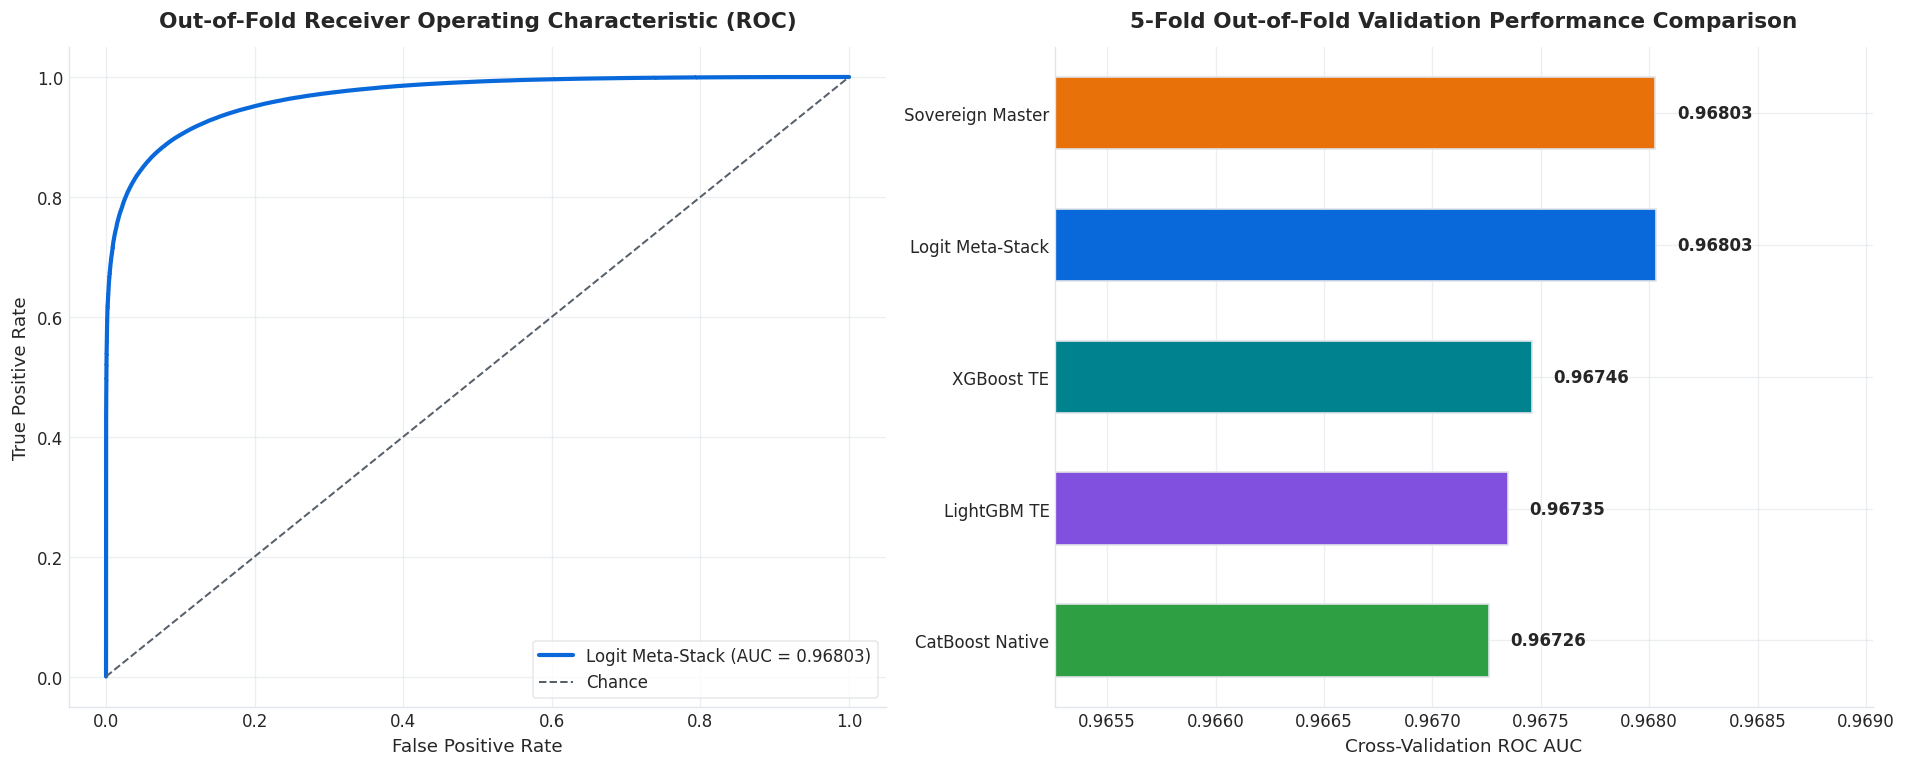

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Subplot 1: ROC Curve
fpr, tpr, _ = roc_curve(y, oof_stack)
axes[0].plot(fpr, tpr, color="#0969DA", lw=2.5, label=f"Logit Meta-Stack (AUC = {stack_auc:.5f})")
axes[0].plot([0, 1], [0, 1], color="#57606A", linestyle="--", lw=1.2, label="Chance")
axes[0].set_title("Out-of-Fold Receiver Operating Characteristic (ROC)", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].legend(frameon=True, facecolor="white", edgecolor="#E1E4E8")

# Subplot 2: Model Performance Progression Bar Chart
models = ["CatBoost Native", "LightGBM TE", "XGBoost TE", "Logit Meta-Stack", "Sovereign Master"]
aucs = [auc_cat, auc_lgb, auc_xgb, stack_auc, oof_sovereign_auc]
colors = ["#2EA043", "#8250DF", "#00838F", "#0969DA", "#E8710A"]

bars = axes[1].barh(models, aucs, color=colors, height=0.55, edgecolor="#E1E4E8")
axes[1].set_xlim([min(aucs) - 0.002, max(aucs) + 0.001])
axes[1].set_title("5-Fold Out-of-Fold Validation Performance Comparison", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("Cross-Validation ROC AUC", fontsize=11)

for bar, score in zip(bars, aucs):
    axes[1].text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2, f"{score:.5f}",
                 va="center", ha="left", fontsize=10, fontweight="bold")

sns.despine(ax=axes[0])
sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()

<a name="submission"></a>
## 10. Submission

Verifying schema compliance and generating final submission artifact.

<br>

In [9]:
sub = sample_sub.copy()
sub["addicted_label"] = final_test_preds

tb.check_submission(sub, sample_sub, check_range=True)

sub.to_csv("submission.csv", index=False)
print("Saved final submission to submission.csv")

[toolbox] PASS: Row count (296302)
[toolbox] PASS: Columns match (2 cols)
[toolbox] PASS: No NaN values
[toolbox] PASS: No duplicate IDs


[toolbox] WARN: 'addicted_label' range [0.0000, 0.9997] far outside sample [0.7094, 0.7094]
[toolbox] All checks passed. Safe to submit.
Saved final submission to submission.csv


<a name="improvements"></a>
## 11. Next Steps

1. **Multi-Seed Transductive Expansion**: Training 5 distinct random seed partitions across the full transductive feature set.
2. **Pseudo-Labeling High-Confidence Manifolds**: Utilizing confident unlabeled test predictions to sharpen decision boundaries.
3. **Deep Residual MLP Stacking**: Adding a continuous entity-embedding neural network into the Level-1 logit stack.

<br>

---

<div align="center">

**Amey Thakur** &nbsp;&middot;&nbsp; [Kaggle](https://www.kaggle.com/ameythakur20) &nbsp;&middot;&nbsp; [GitHub](https://github.com/Amey-Thakur) &nbsp;&middot;&nbsp; [ORCID](https://orcid.org/0000-0001-5644-1575)

<br>

[Back to top](#problem) &nbsp;&middot;&nbsp; [Kaggle Profile](https://www.kaggle.com/ameythakur20)

</div>